In [1]:
library(ggplot2)
library(plyr)
library(dplyr)
library(tidyr)

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [7]:
exp <- read.table('mouseAD_seurat_avg_expression_per_mouse_44interaction_up_genes.tsv')

In [18]:
exp$time <- as.character(exp$time)

In [19]:
head(exp)

,Apobec1,Rad51b,Gnas,H2.K1,Fblim1,Tmem106a,C030034L19Rik,Rassf3,Neat1,Cacna1d,⋯,Mdfic,Lyz2,Cd300lf,Gm13391,Vps18,Trps1,Cnr2,group,genotype,time
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
WT.3M_3C.Xu.1.2,1.2970473,0.4168031,3.554530,0.3303162,0.3596401,0.13747576,0.02560098,1.0379370,0.7424074,3.495112,⋯,0.08903628,0.00000000,0.05894640,0.04028441,0.3298169,0.3849442,0.06587753,WT.3M_3C.Xu.1.2,WT,3
AD.3M_9C.Xu.1.2,1.5017120,0.8054768,3.117388,0.4857854,0.3447213,0.08146623,0.16489108,1.8296906,0.6123983,3.038406,⋯,0.09925213,0.17754245,0.08003693,0.13779035,0.3590883,0.7067911,0.06058729,AD.3M_9C.Xu.1.2,AD,3
WT.3M_15C.Xu.1.2,1.2668099,0.6583506,2.713642,0.4688637,0.2146373,0.06651995,0.00000000,1.3364164,0.5744744,3.672077,⋯,0.09876999,0.07404295,0.00000000,0.06697631,0.3286923,0.5493970,0.21162261,WT.3M_15C.Xu.1.2,WT,3
AD.3M_21C.Xu.1.2,1.6076777,0.7353043,3.552911,0.8876031,0.3554970,0.42361386,0.00000000,1.6390790,1.2825880,5.103394,⋯,0.19867556,0.28380616,0.28425615,0.20820850,0.3643440,0.5533792,0.35145175,AD.3M_21C.Xu.1.2,AD,3
WT.3M_4C.Xu.1.2,0.0000000,0.0000000,2.116402,2.1710812,2.1645022,0.00000000,0.00000000,0.0000000,0.0000000,6.261649,⋯,0.00000000,2.05846027,0.00000000,0.00000000,0.0000000,2.1164021,0.00000000,WT.3M_4C.Xu.1.2,WT,3
AD.3M_10C.Xu.1.2,0.9831669,1.2358812,3.502580,1.1755591,0.1551050,0.00000000,0.26378591,0.7660964,0.3989358,4.658717,⋯,0.52648012,1.04183524,0.00000000,0.00000000,0.6685236,0.3610861,0.21106757,AD.3M_10C.Xu.1.2,AD,3


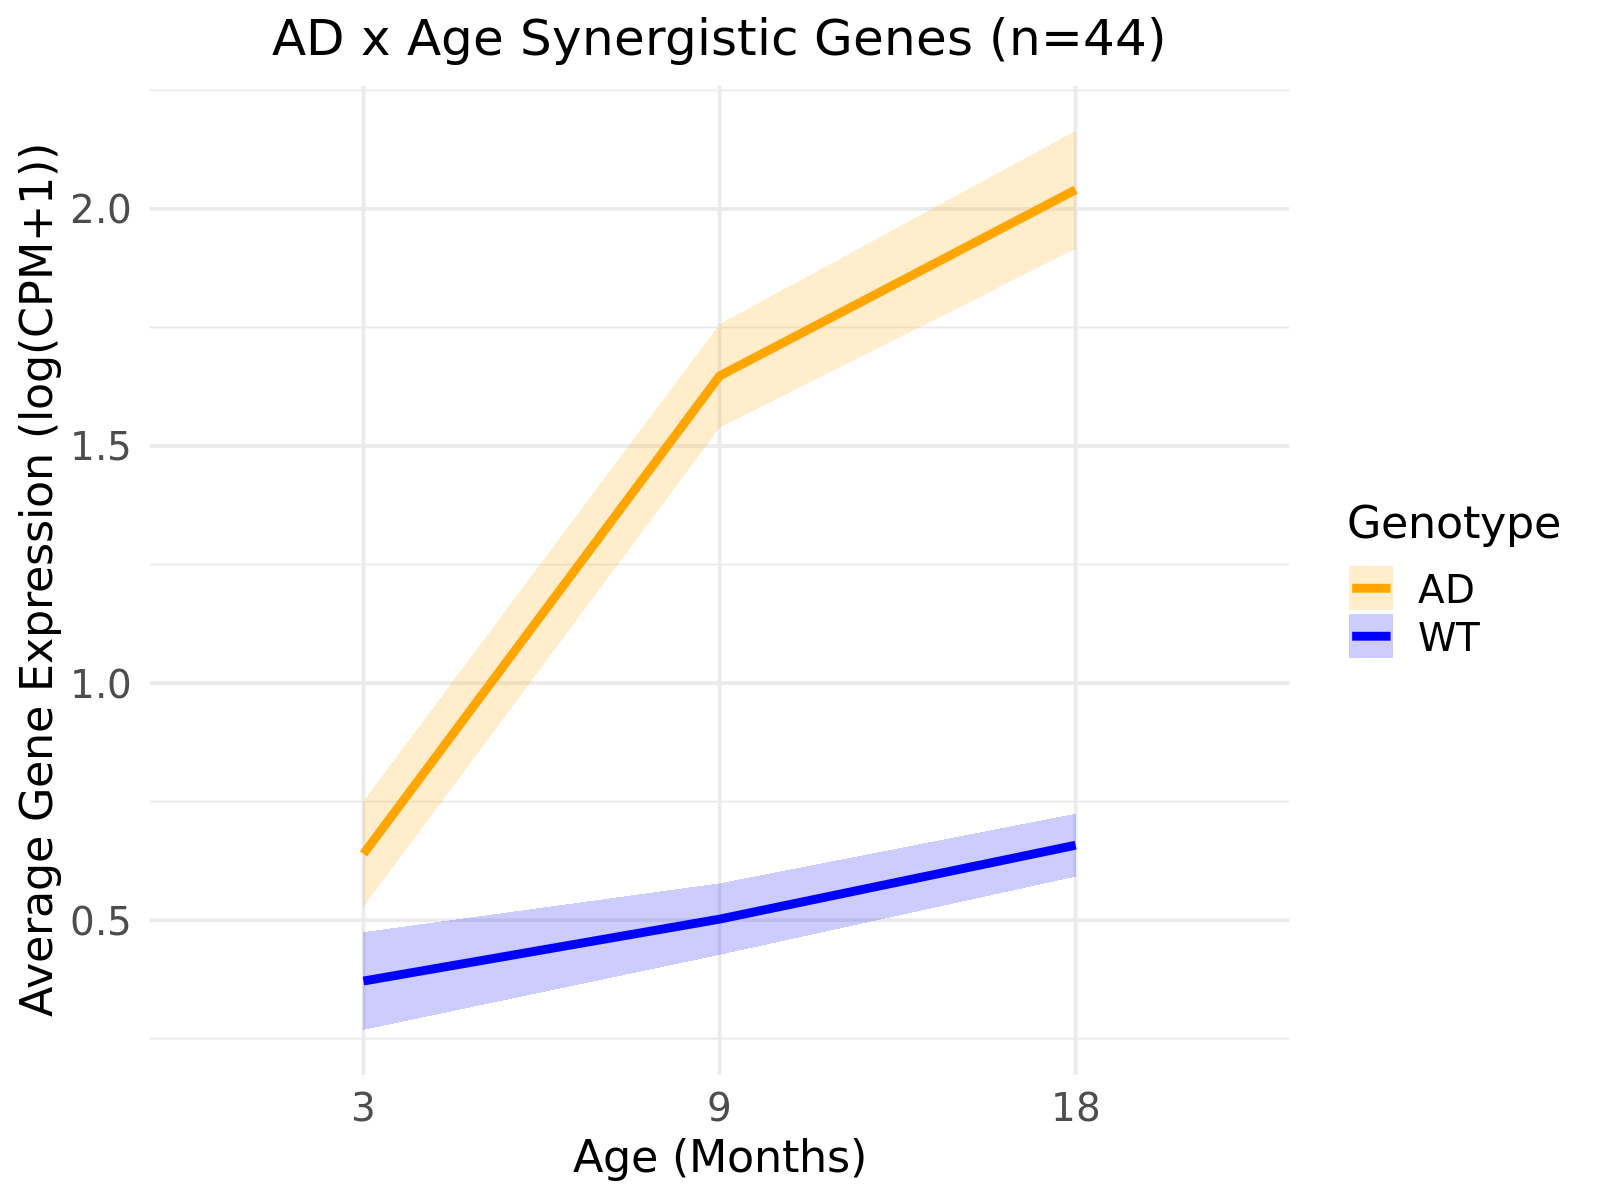

In [31]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)

# Reshape the data to long format
exp_long <- exp %>%
  pivot_longer(
    cols = 1:44,  # Columns 1 to 44 as y-values
    names_to = "variable",
    values_to = "value"
  )

# Calculate the mean and confidence interval for each group
exp_avg <- exp_long %>%
  group_by(genotype, time) %>%
  summarize(
    mean_value = mean(value, na.rm = TRUE),
    n = n(),  # Number of samples
    sd = sd(value, na.rm = TRUE),
    t = qt(0.975, df = n() - 1),  # t-value for 95% CI
    ci = t * sd / sqrt(n),  # Confidence interval
    .groups = "drop"
  )

# Set the order of x-axis values (time)
exp_avg$time <- factor(exp_avg$time, levels = c(3, 9, 18))

# Custom colors for genotypes
custom_colors <- c("orange", "blue")

# Plot with customizations
bd <- ggplot(exp_avg, aes(x = time, y = mean_value, color = genotype, group = genotype)) +
  geom_line(size = 1.5) +  # Line plot
  geom_ribbon(aes(ymin = mean_value - ci, ymax = mean_value + ci, fill = genotype), 
              alpha = 0.2, color = NA) +  # Shaded area for confidence interval
  scale_color_manual(values = custom_colors) +  # Set custom line colors
  scale_fill_manual(values = custom_colors) +  # Set custom fill colors
  theme_minimal(base_size = 14) +  # Increase base font size for all text
  labs(
    title = "AD x Age Synergistic Genes (n=44)",
    x = "Age (Months)",
    y = "Average Gene Expression (log(CPM+1))",
    color = "Genotype",
    fill = "Genotype"
  ) +
  theme(
    axis.text = element_text(size = 14),  # Increase size of axis text
    axis.title = element_text(size = 16), # Increase size of axis titles
    legend.text = element_text(size = 14), # Increase size of legend text
    legend.title = element_text(size = 16), # Increase size of legend title
    plot.title = element_text(size = 18, hjust = 0.5) # Increase and center-align title
  )

bd
#ggsave("../../ggsave_plots/synergistic_genes_avg_CI_ribbon.pdf", plot=bd, font='Helvetica', device="pdf", width=8, height=6)

In [6]:
library(ggplot2)
library(plyr)
library(dplyr)
library(tidyr)

In [7]:
exp <- read.table('mouseAD_seurat_avg_expression_per_mouse_44interaction_up_genes.tsv')

In [18]:
exp$time <- as.character(exp$time)

In [19]:
head(exp)

,Apobec1,Rad51b,Gnas,H2.K1,Fblim1,Tmem106a,C030034L19Rik,Rassf3,Neat1,Cacna1d,⋯,Mdfic,Lyz2,Cd300lf,Gm13391,Vps18,Trps1,Cnr2,group,genotype,time
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
WT.3M_3C.Xu.1.2,1.2970473,0.4168031,3.554530,0.3303162,0.3596401,0.13747576,0.02560098,1.0379370,0.7424074,3.495112,⋯,0.08903628,0.00000000,0.05894640,0.04028441,0.3298169,0.3849442,0.06587753,WT.3M_3C.Xu.1.2,WT,3
AD.3M_9C.Xu.1.2,1.5017120,0.8054768,3.117388,0.4857854,0.3447213,0.08146623,0.16489108,1.8296906,0.6123983,3.038406,⋯,0.09925213,0.17754245,0.08003693,0.13779035,0.3590883,0.7067911,0.06058729,AD.3M_9C.Xu.1.2,AD,3
WT.3M_15C.Xu.1.2,1.2668099,0.6583506,2.713642,0.4688637,0.2146373,0.06651995,0.00000000,1.3364164,0.5744744,3.672077,⋯,0.09876999,0.07404295,0.00000000,0.06697631,0.3286923,0.5493970,0.21162261,WT.3M_15C.Xu.1.2,WT,3
AD.3M_21C.Xu.1.2,1.6076777,0.7353043,3.552911,0.8876031,0.3554970,0.42361386,0.00000000,1.6390790,1.2825880,5.103394,⋯,0.19867556,0.28380616,0.28425615,0.20820850,0.3643440,0.5533792,0.35145175,AD.3M_21C.Xu.1.2,AD,3
WT.3M_4C.Xu.1.2,0.0000000,0.0000000,2.116402,2.1710812,2.1645022,0.00000000,0.00000000,0.0000000,0.0000000,6.261649,⋯,0.00000000,2.05846027,0.00000000,0.00000000,0.0000000,2.1164021,0.00000000,WT.3M_4C.Xu.1.2,WT,3
AD.3M_10C.Xu.1.2,0.9831669,1.2358812,3.502580,1.1755591,0.1551050,0.00000000,0.26378591,0.7660964,0.3989358,4.658717,⋯,0.52648012,1.04183524,0.00000000,0.00000000,0.6685236,0.3610861,0.21106757,AD.3M_10C.Xu.1.2,AD,3


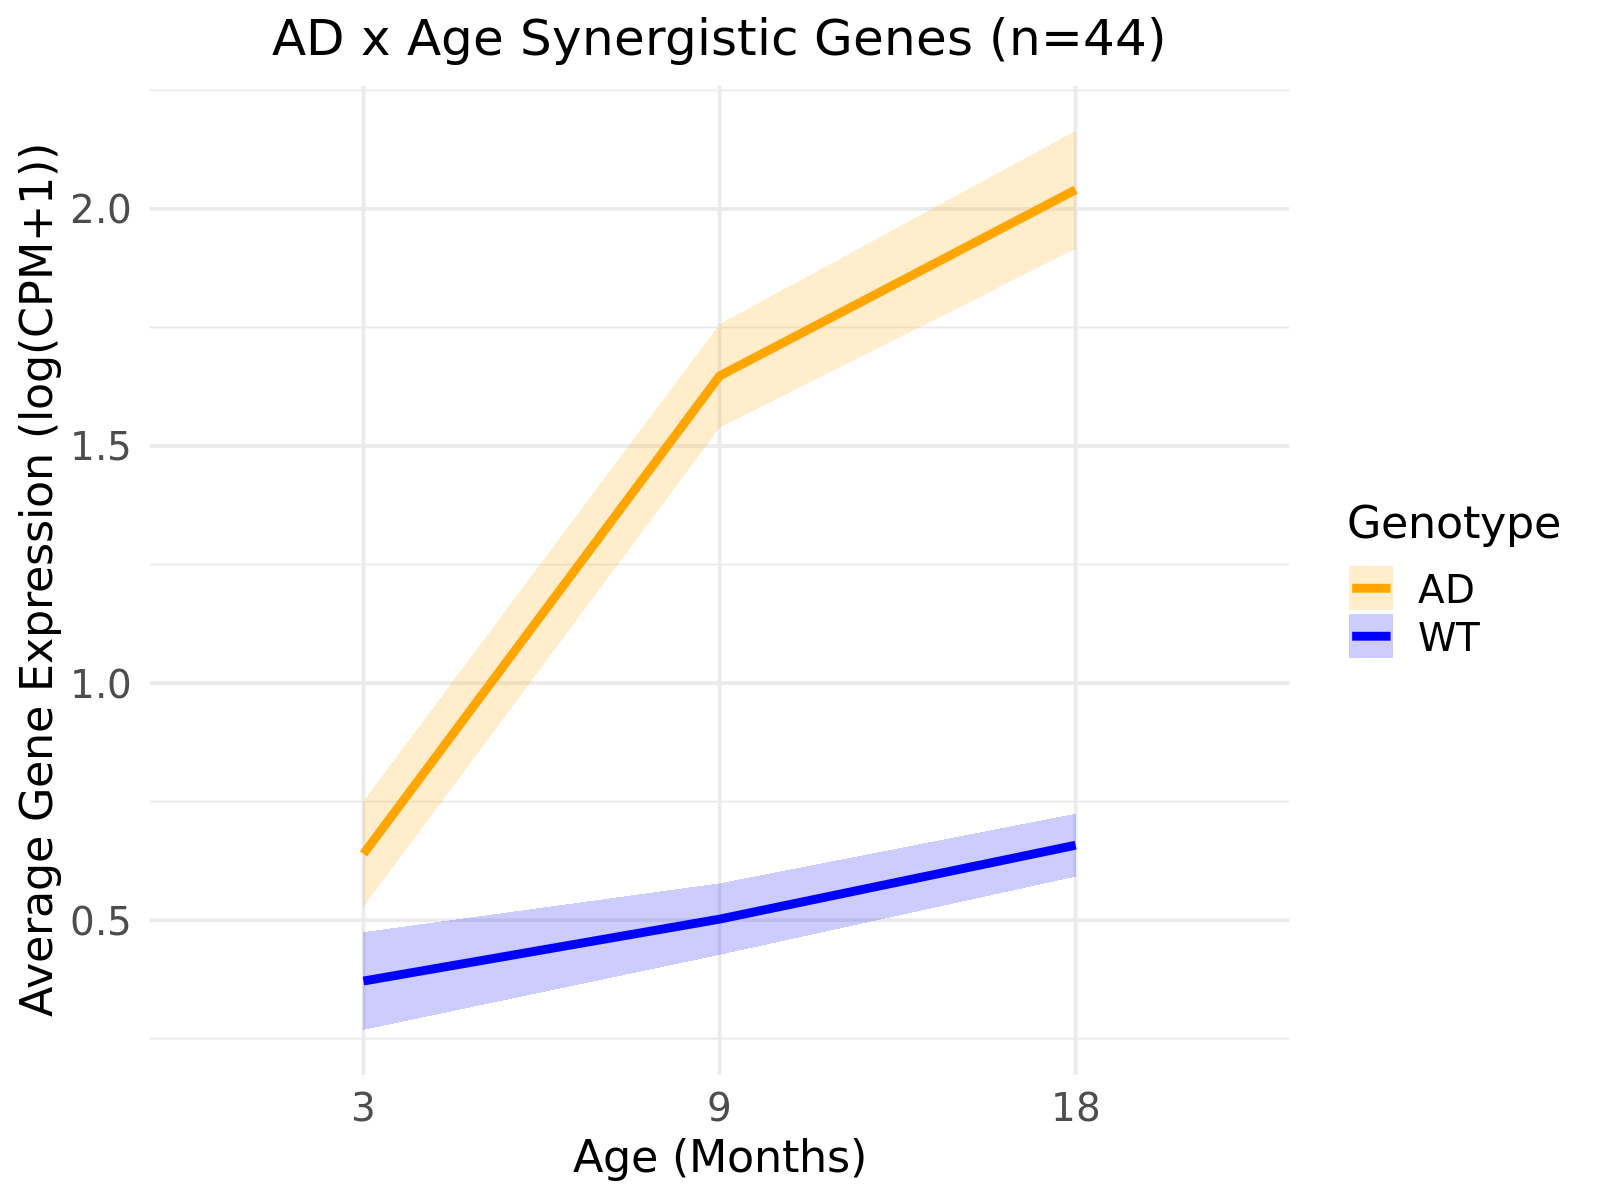

In [31]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)

# Reshape the data to long format
exp_long <- exp %>%
  pivot_longer(
    cols = 1:44,  # Columns 1 to 44 as y-values
    names_to = "variable",
    values_to = "value"
  )

# Calculate the mean and confidence interval for each group
exp_avg <- exp_long %>%
  group_by(genotype, time) %>%
  summarize(
    mean_value = mean(value, na.rm = TRUE),
    n = n(),  # Number of samples
    sd = sd(value, na.rm = TRUE),
    t = qt(0.975, df = n() - 1),  # t-value for 95% CI
    ci = t * sd / sqrt(n),  # Confidence interval
    .groups = "drop"
  )

# Set the order of x-axis values (time)
exp_avg$time <- factor(exp_avg$time, levels = c(3, 9, 18))

# Custom colors for genotypes
custom_colors <- c("orange", "blue")

# Plot with customizations
bd <- ggplot(exp_avg, aes(x = time, y = mean_value, color = genotype, group = genotype)) +
  geom_line(size = 1.5) +  # Line plot
  geom_ribbon(aes(ymin = mean_value - ci, ymax = mean_value + ci, fill = genotype), 
              alpha = 0.2, color = NA) +  # Shaded area for confidence interval
  scale_color_manual(values = custom_colors) +  # Set custom line colors
  scale_fill_manual(values = custom_colors) +  # Set custom fill colors
  theme_minimal(base_size = 14) +  # Increase base font size for all text
  labs(
    title = "AD x Age Synergistic Genes (n=44)",
    x = "Age (Months)",
    y = "Average Gene Expression (log(CPM+1))",
    color = "Genotype",
    fill = "Genotype"
  ) +
  theme(
    axis.text = element_text(size = 14),  # Increase size of axis text
    axis.title = element_text(size = 16), # Increase size of axis titles
    legend.text = element_text(size = 14), # Increase size of legend text
    legend.title = element_text(size = 16), # Increase size of legend title
    plot.title = element_text(size = 18, hjust = 0.5) # Increase and center-align title
  )

bd
#ggsave("../../ggsave_plots/synergistic_genes_avg_CI_ribbon.pdf", plot=bd, font='Helvetica', device="pdf", width=8, height=6)